<a href="https://colab.research.google.com/github/dusandvorakcz-png/EDA-Smartwatch-Sleep-Track-Data/blob/main/EDA_Smartwatch_Sleep_Tracking_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 SETUP

In [1]:
import kagglehub

path = kagglehub.dataset_download("mirzayasirabdullah07/smartwatch-sleep-tracking-dataset-20182025")
print(path)

Using Colab cache for faster access to the 'smartwatch-sleep-tracking-dataset-20182025' dataset.
/kaggle/input/smartwatch-sleep-tracking-dataset-20182025


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🔗 LOAD DATASET FROM KAGGLE

In [3]:
df = pd.read_csv(f"{path}/smartwatch_sleep_dataset.csv")
df

,user_id,date_recorded,sleep_start_timestamp,sleep_end_timestamp,duration_minutes,sleep_latency_minutes,wake_after_sleep_onset_minutes,sleep_efficiency_pct,sleep_score,daily_label,...,height_cm,device_model,bedtime_consistency_std_min,stress_score,activity_before_bed_min,screen_time_before_bed_min,insomnia_flag,apnea_risk_score,nap_duration_minutes,created_at
0,user_00332,2024-04-03,2024-04-03 22:36:00,2024-04-04 06:01:00,445,2,15,96.2,59,fair,...,166.1,AlphaWatch X1,37.1,33,39,87,0,24,10,2025-10-21 16:41:53.708868
1,user_00677,2018-12-05,2018-12-05 23:41:00,2018-12-06 04:36:00,295,18,1,93.6,61,fair,...,172.4,AlphaWatch X1,9.6,20,1,0,0,15,9,2025-10-21 16:41:53.709912
2,user_01815,2025-03-30,2025-03-30 23:41:00,2025-03-31 06:56:00,435,6,50,87.1,58,fair,...,158.0,PulsePro 3,35.5,29,5,37,0,33,0,2025-10-21 16:41:53.711057
3,user_00488,2023-05-11,2023-05-11 22:24:00,2023-05-12 06:10:00,466,10,12,95.3,53,fair,...,152.6,WristFit Z,65.4,41,69,71,0,8,3,2025-10-21 16:41:53.712147
4,user_00498,2019-12-11,2019-12-11 22:17:00,2019-12-12 04:29:00,372,1,2,99.2,60,fair,...,155.1,WristFit Z,0.4,54,49,31,0,26,5,2025-10-21 16:41:53.713204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,user_01924,2019-02-11,2019-02-11 23:05:00,2019-02-12 07:38:00,513,0,31,94.0,58,fair,...,159.2,PulsePro 3,52.6,46,80,121,0,9,0,2025-10-21 16:42:15.166198
19996,user_00870,2025-08-31,2025-08-31 22:41:00,2025-09-01 06:26:00,465,10,8,96.1,56,fair,...,178.9,OpenSmart v2,40.3,42,78,94,0,0,0,2025-10-21 16:42:15.167269
19997,user_01642,2018-08-02,2018-08-02 00:06:00,2018-08-02 06:17:00,371,4,19,93.8,62,fair,...,167.7,WristFit Z,7.8,26,0,106,0,30,1,2025-10-21 16:42:15.168288
19998,user_01443,2021-10-09,2021-10-09 22:51:00,2021-10-10 06:33:00,462,23,0,95.0,49,poor,...,168.9,WristFit Z,41.8,44,39,57,0,0,1,2025-10-21 16:42:15.169373


# 👀 FIRST LOOK

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         20000 non-null  object 
 1   date_recorded                   20000 non-null  object 
 2   sleep_start_timestamp           20000 non-null  object 
 3   sleep_end_timestamp             20000 non-null  object 
 4   duration_minutes                20000 non-null  int64  
 5   sleep_latency_minutes           20000 non-null  int64  
 6   wake_after_sleep_onset_minutes  20000 non-null  int64  
 7   sleep_efficiency_pct            20000 non-null  float64
 8   sleep_score                     20000 non-null  int64  
 9   daily_label                     20000 non-null  object 
 10  sleep_stage_deep_pct            20000 non-null  float64
 11  sleep_stage_light_pct           20000 non-null  float64
 12  sleep_stage_rem_pct             

In [5]:
df.describe()

,duration_minutes,sleep_latency_minutes,wake_after_sleep_onset_minutes,sleep_efficiency_pct,sleep_score,sleep_stage_deep_pct,sleep_stage_light_pct,sleep_stage_rem_pct,sleep_stage_awake_pct,heart_rate_mean_bpm,...,age,weight_kg,height_cm,bedtime_consistency_std_min,stress_score,activity_before_bed_min,screen_time_before_bed_min,insomnia_flag,apnea_risk_score,nap_duration_minutes
count,20000.000000,20000.000000,20000.0000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.0000,20000.000000,20000.00000,20000.000000
mean,449.188850,9.660300,19.5573,93.318930,57.861950,17.958485,52.061990,19.928820,10.050460,60.059010,...,48.309250,75.367360,170.43094,32.783585,34.819750,40.952350,56.1891,0.021200,12.32130,4.452400
std,71.884421,10.171415,19.7675,5.272647,5.368606,5.901501,6.372894,4.904652,6.960017,7.507331,...,17.544677,15.106742,9.72220,21.144093,17.490442,27.652919,36.9583,0.144054,10.86883,4.893223
min,151.000000,0.000000,0.0000,59.500000,31.000000,5.000000,27.100000,8.000000,0.000000,36.400000,...,18.000000,22.800000,139.30000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.000000
25%,400.000000,2.000000,5.0000,91.000000,55.000000,13.900000,47.700000,16.600000,5.000000,54.900000,...,33.000000,65.300000,163.60000,15.700000,22.000000,20.000000,28.0000,0.000000,3.00000,1.000000
50%,449.000000,7.000000,13.0000,94.700000,58.000000,18.000000,52.200000,20.000000,8.100000,60.000000,...,49.000000,75.200000,170.70000,30.400000,34.000000,39.000000,55.0000,0.000000,11.00000,3.000000
75%,498.000000,13.000000,28.0000,97.100000,62.000000,22.000000,56.500000,23.300000,14.000000,65.200000,...,63.000000,85.500000,176.80000,47.000000,47.000000,60.000000,82.0000,0.000000,19.00000,6.000000
max,720.000000,102.000000,141.0000,100.000000,76.000000,35.000000,76.200000,30.000000,42.800000,98.400000,...,79.000000,120.000000,202.40000,123.300000,100.000000,157.000000,210.0000,1.000000,59.00000,43.000000


# 🧹 DATA QUALITY AND CLEANING

In [6]:
df.duplicated().sum() #There are no fully-identical rows

np.int64(0)

In [7]:
df.columns

Index(['user_id', 'date_recorded', 'sleep_start_timestamp',
       'sleep_end_timestamp', 'duration_minutes', 'sleep_latency_minutes',
       'wake_after_sleep_onset_minutes', 'sleep_efficiency_pct', 'sleep_score',
       'daily_label', 'sleep_stage_deep_pct', 'sleep_stage_light_pct',
       'sleep_stage_rem_pct', 'sleep_stage_awake_pct', 'heart_rate_mean_bpm',
       'heart_rate_min_bpm', 'heart_rate_max_bpm', 'hrv_rmssd_ms',
       'respiration_rate_bpm', 'spo2_mean_pct', 'spo2_min_pct',
       'movement_count', 'snore_events', 'ambient_noise_db',
       'room_temperature_c', 'room_humidity_pct', 'step_count_day',
       'caffeine_mg', 'alcohol_units', 'medication_flag', 'jetlag_hours',
       'timezone', 'age', 'gender', 'weight_kg', 'height_cm', 'device_model',
       'bedtime_consistency_std_min', 'stress_score',
       'activity_before_bed_min', 'screen_time_before_bed_min',
       'insomnia_flag', 'apnea_risk_score', 'nap_duration_minutes',
       'created_at'],
      dtype='obj

In [8]:
#Inspecting heart rate min bpm

df[["user_id",
    "heart_rate_min_bpm",
    "heart_rate_mean_bpm",
    "spo2_min_pct",
    "duration_minutes",
    "sleep_score"]].sort_values(by="heart_rate_min_bpm").head(10)

,user_id,heart_rate_min_bpm,heart_rate_mean_bpm,spo2_min_pct,duration_minutes,sleep_score
18044,user_00507,25.6,39.8,97.2,474,56
8180,user_00713,27.0,39.3,96.3,455,64
4373,user_01329,27.4,40.7,96.3,419,58
3681,user_01511,28.2,39.0,93.8,487,60
15068,user_00796,28.7,38.1,93.9,441,69
4960,user_01356,29.3,43.9,94.6,577,52
16407,user_00297,29.3,36.5,95.7,417,49
7303,user_00988,29.8,44.2,96.8,469,54
2833,user_00390,29.8,36.4,99.6,316,62
11532,user_01155,29.9,42.6,97.0,464,59


In [9]:
#Inspecting SpO2 maximum value

df[["user_id",
    "heart_rate_min_bpm",
    "heart_rate_mean_bpm",
    "spo2_min_pct",
    "duration_minutes",
    "sleep_score"]].sort_values(by="spo2_min_pct", ascending = False).head(10)

,user_id,heart_rate_min_bpm,heart_rate_mean_bpm,spo2_min_pct,duration_minutes,sleep_score
9151,user_00624,56.4,60.1,100.0,422,66
10220,user_00520,35.3,43.8,100.0,481,56
6142,user_01288,44.8,56.8,100.0,306,52
19077,user_01595,44.7,52.3,99.9,432,55
11630,user_01305,58.8,62.9,99.9,504,59
13520,user_01344,49.7,56.7,99.9,487,63
9923,user_01276,54.6,55.0,99.9,411,60
7721,user_00910,42.8,51.1,99.9,465,72
4778,user_01452,55.9,57.0,99.9,421,64
9303,user_01917,60.9,66.6,99.9,507,52


I inspected SpO2 (max 100% which doesn't exceed the 100% physical limit) and the lowest minimum heart rates (down to 25.6 bpm). All values are physiologically plausible, so no rows were removed.

# 📊 UNIVARIATE ANALYSIS

In [10]:
df["daily_label"].value_counts()

,count
daily_label,
fair,18666
poor,1330
good,4


In [11]:
device_model_counts = df["device_model"].value_counts().sort_values(ascending=False)
total_count = device_model_counts.sum()
percentages = (device_model_counts / total_count * 100).round(2)

result_df = pd.DataFrame({
    "Count": device_model_counts,
    "%": percentages.apply(lambda x: f"{x}%"),
})

result_df

,Count,%
device_model,,
AlphaWatch X1,5100,25.5%
PulsePro 3,4764,23.82%
SleepSense S2,4202,21.01%
WristFit Z,4110,20.55%
OpenSmart v2,1824,9.12%


In [12]:
df["deep_sleep_minutes"] = df["duration_minutes"] * (df["sleep_stage_deep_pct"]/100)
df["deep_sleep_minutes"].describe()

,deep_sleep_minutes
count,20000.000000
mean,80.674561
std,29.788078
min,12.080000
25%,59.473000
50%,78.913000
75%,99.703250
max,213.995000


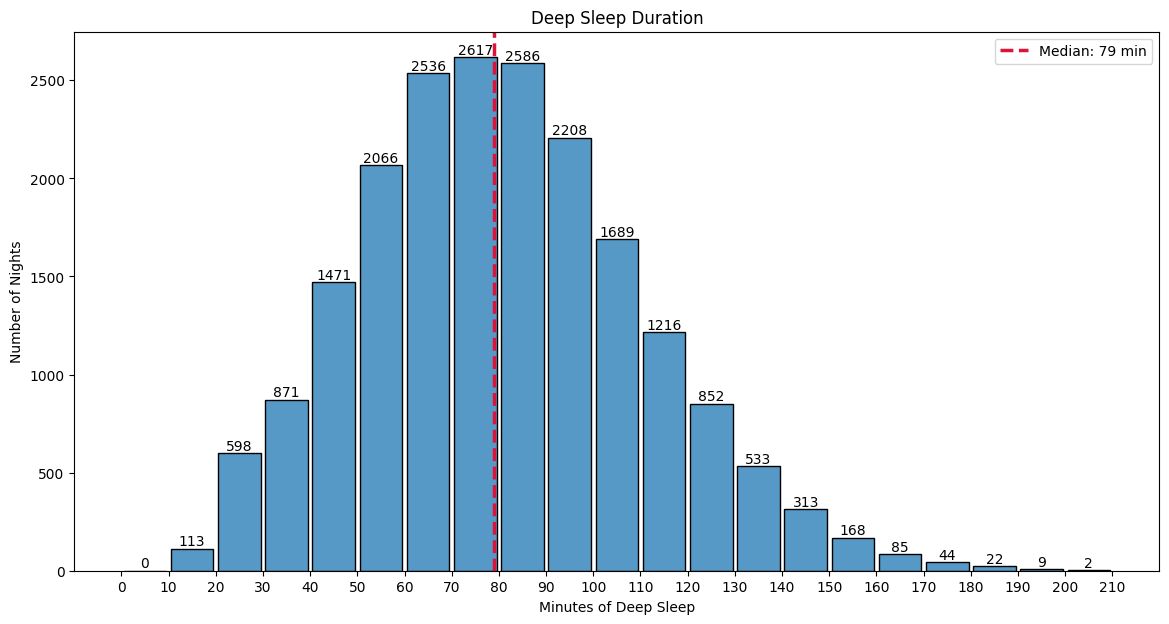

In [13]:
plt.figure(figsize=(14,7))
median_value = df["deep_sleep_minutes"].median()

sns.histplot(data = df["deep_sleep_minutes"],
             bins=range(0,220,10),
             shrink = 0.9
             )

plt.title("Deep Sleep Duration")
plt.xlabel("Minutes of Deep Sleep")
plt.xticks(range(0,220,10))
plt.ylabel("Number of Nights")
plt.bar_label(plt.gca().containers[0])
plt.axvline(x=median_value, color="crimson", linestyle="--", label=f"Median: {median_value:.0f} min", linewidth=2.5)
plt.legend()

plt.show()

In [14]:
round(7739/len(df)*100)

39

Deep sleep is bell-shaped with a slight right skew, which tells us there are a few nights with a high number of minutes in the deep sleep stage. Most nights (7739 nights, about 39%) fall between 60 and 90 minutes of deep sleep, with a median of approx. 79 minutes.

In [15]:
df.duplicated("user_id").sum()

np.int64(18000)

In [16]:
df["user_id"].nunique()

2000

There are 18000 duplicate user_ids, which confirms 2000 unique users with multiple nights each.

In [17]:
unique_users = df.drop_duplicates("user_id")

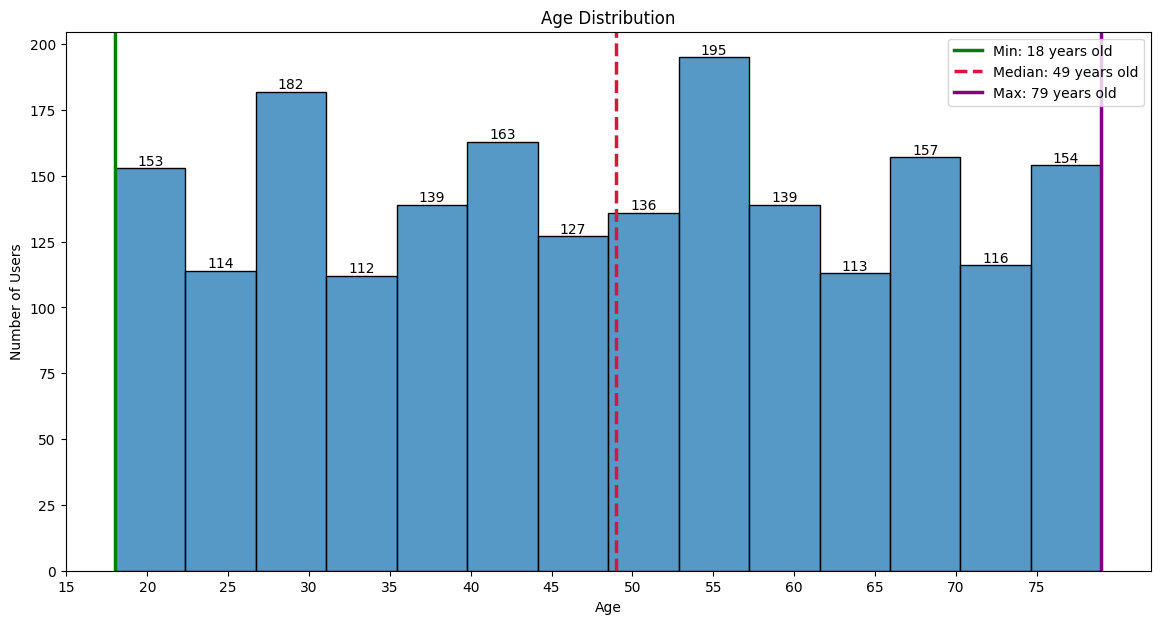

In [18]:
plt.figure(figsize=(14,7))
median_age = unique_users["age"].median()
min_age = unique_users["age"].min()
max_age = unique_users["age"].max()

sns.histplot(data = unique_users["age"])

plt.xticks(range(15,80,5))
plt.bar_label(plt.gca().containers[0])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.axvline(x=min_age, color="green", linestyle="-", label=f"Min: {min_age:.0f} years old", linewidth=2.5)
plt.axvline(x=median_age, color="crimson", linestyle="--", label=f"Median: {median_age:.0f} years old", linewidth=2.5)
plt.axvline(x=max_age, color="purple", linestyle="-", label=f"Max: {max_age:.0f} years old", linewidth=2.5)
plt.legend()

plt.show()

Among the 2000 unique users, ages are spread fairly evenly from 18 to 79 (median 49), with no age group over or under-represented. The even spread reflects synthetic sample. Coverage is good enough to compare deep sleep across ages reliably.

# 🔥 BIVARIATE ANALYSIS

In [19]:
df.columns

Index(['user_id', 'date_recorded', 'sleep_start_timestamp',
       'sleep_end_timestamp', 'duration_minutes', 'sleep_latency_minutes',
       'wake_after_sleep_onset_minutes', 'sleep_efficiency_pct', 'sleep_score',
       'daily_label', 'sleep_stage_deep_pct', 'sleep_stage_light_pct',
       'sleep_stage_rem_pct', 'sleep_stage_awake_pct', 'heart_rate_mean_bpm',
       'heart_rate_min_bpm', 'heart_rate_max_bpm', 'hrv_rmssd_ms',
       'respiration_rate_bpm', 'spo2_mean_pct', 'spo2_min_pct',
       'movement_count', 'snore_events', 'ambient_noise_db',
       'room_temperature_c', 'room_humidity_pct', 'step_count_day',
       'caffeine_mg', 'alcohol_units', 'medication_flag', 'jetlag_hours',
       'timezone', 'age', 'gender', 'weight_kg', 'height_cm', 'device_model',
       'bedtime_consistency_std_min', 'stress_score',
       'activity_before_bed_min', 'screen_time_before_bed_min',
       'insomnia_flag', 'apnea_risk_score', 'nap_duration_minutes',
       'created_at', 'deep_sleep_minut

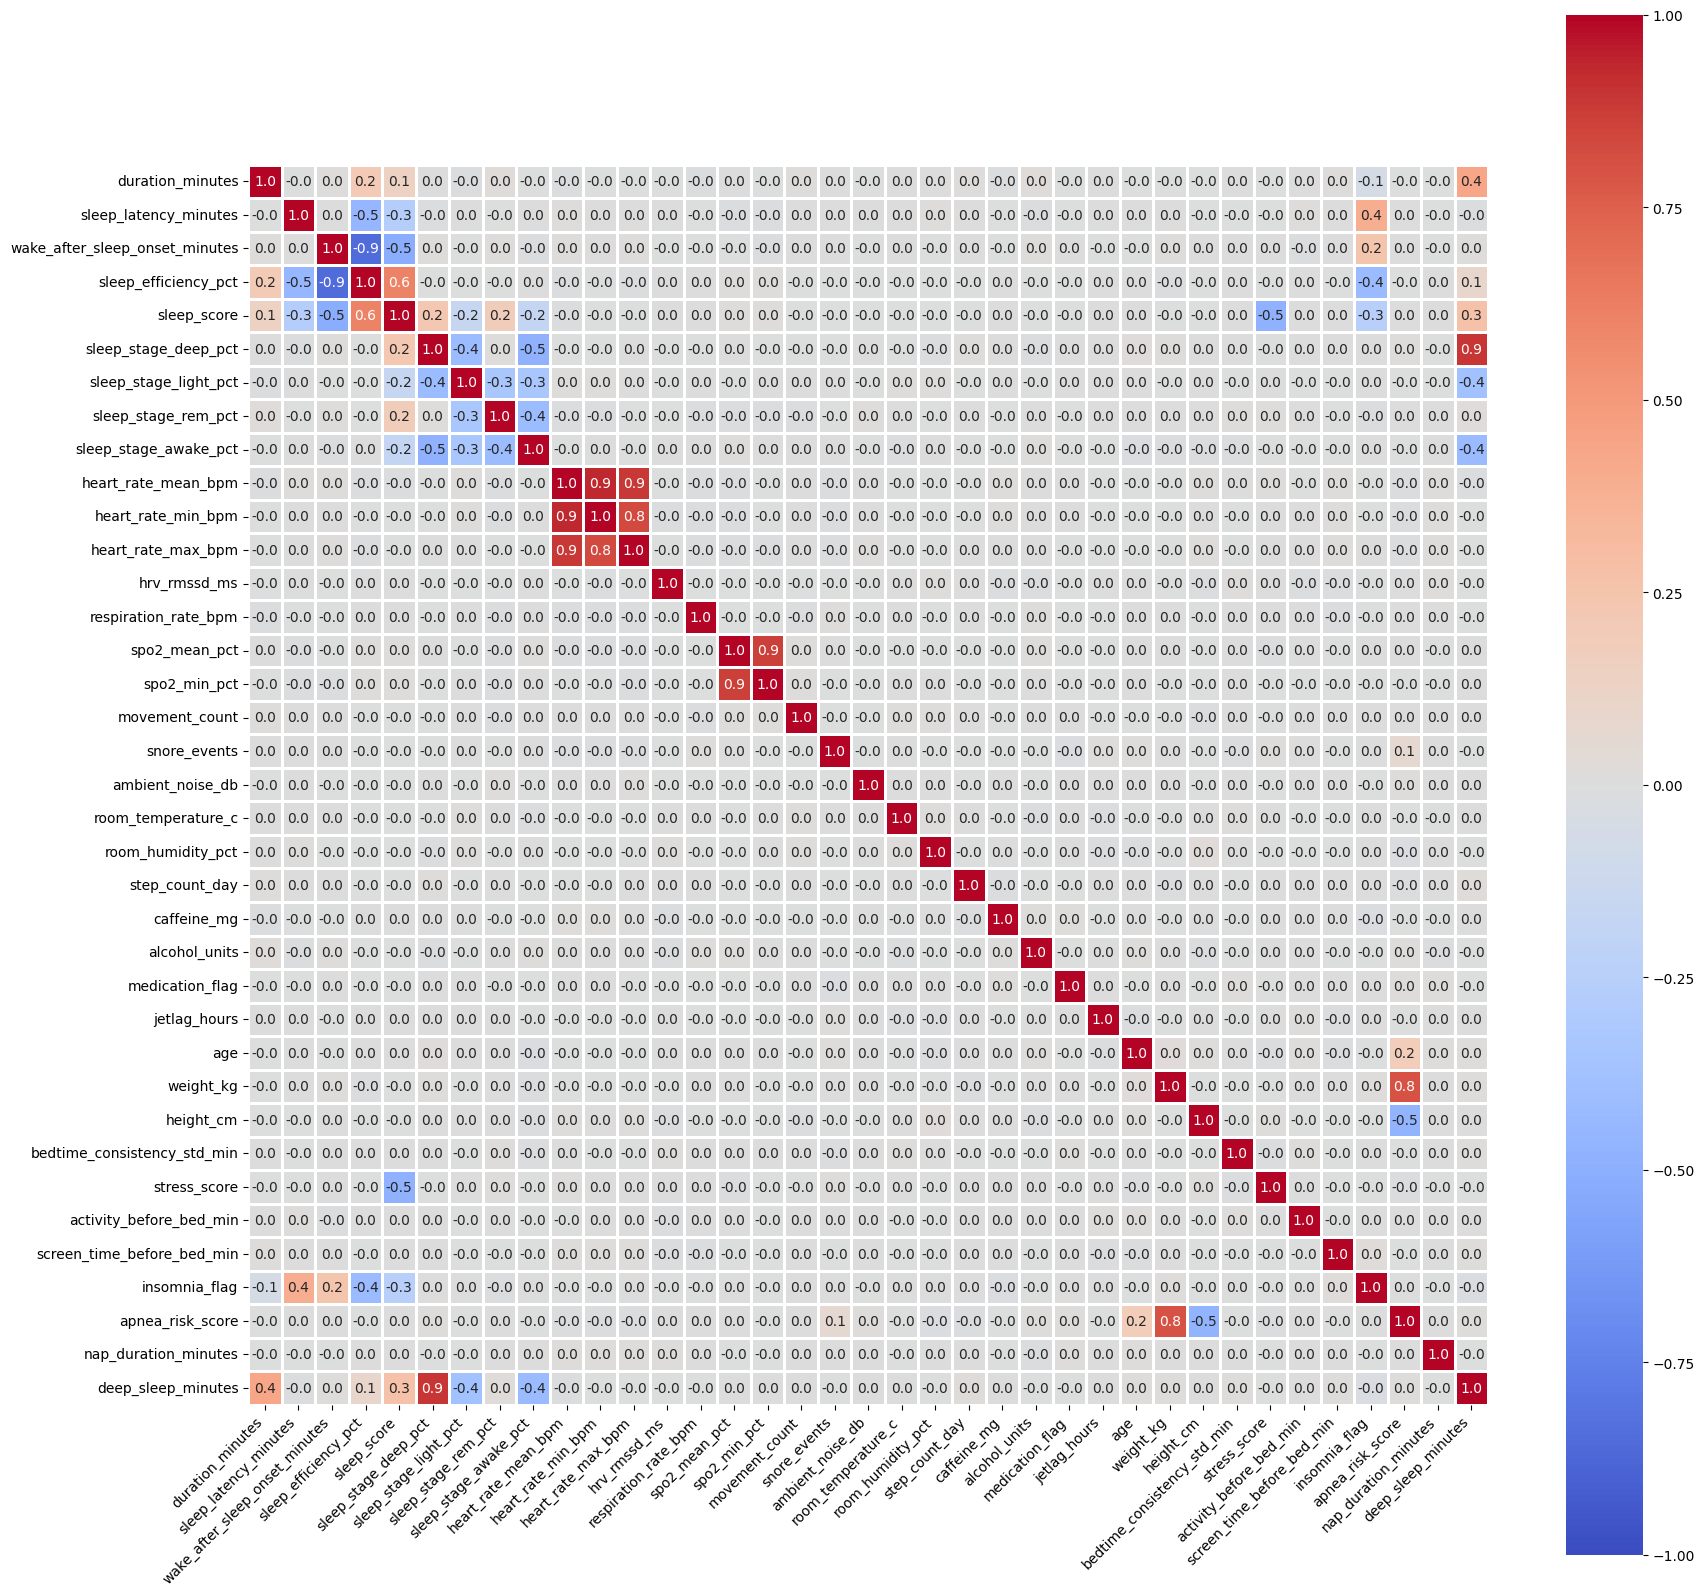

In [20]:
plt.figure(figsize=(20, 20))
ax = sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            square=True,
            fmt=".1f",
            vmin=-1, vmax=1,
            linewidth=1,
            cmap="coolwarm",
            )
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0);

The full correlation matrix shows links, such as weight vs apnea risk (r = 0.8), but no lifestyle factor relates to deep sleep. The deep_sleep_minutes row is red only on the columns it was calculated from (duration_minutes and sleep_stage_deep_pct), so those correlations are not findings.

In [21]:
relevant = ["sleep_score",
            "sleep_efficiency_pct",
            "age",
            "caffeine_mg",
            "alcohol_units",
            "stress_score",
            "screen_time_before_bed_min",
            "step_count_day",
            "weight_kg",
            "apnea_risk_score"]

deep_sleep_corr = df.corr(numeric_only=True)["deep_sleep_minutes"][relevant].sort_values(ascending=False)
squared_corr = (deep_sleep_corr**2)*100

result_deepsleep = pd.DataFrame({
    "Correlation": deep_sleep_corr.round(3),
    "R2 (%)": squared_corr.apply(lambda x: f"{x:.2f}%")
})

result_deepsleep

,Correlation,R2 (%)
sleep_score,0.268,7.18%
sleep_efficiency_pct,0.088,0.78%
step_count_day,0.019,0.04%
age,0.015,0.02%
weight_kg,0.012,0.01%
apnea_risk_score,0.010,0.01%
screen_time_before_bed_min,0.010,0.01%
caffeine_mg,0.000,0.00%
alcohol_units,-0.000,0.00%
stress_score,-0.008,0.01%


Only sleep_score shows a meaningful link to deep sleep (r = 0.27, 7.18%). Every lifestyle and demographic factor (caffeine, alcohol, stress, screen time, exercise, age, weight) sits near zero, so none is associated with deep sleep in this dataset.

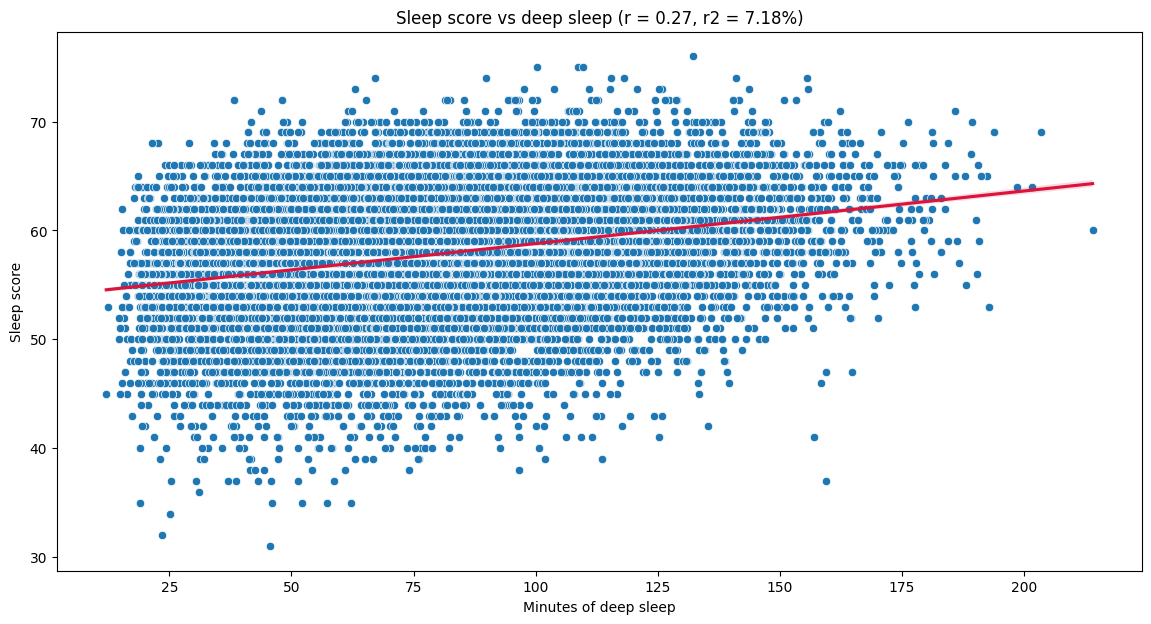

In [22]:
r = df["deep_sleep_minutes"].corr(df["sleep_score"])
r_squared = (r**2)*100

plt.figure(figsize=(14, 7))

sns.scatterplot(data=df,
                x="deep_sleep_minutes",
                y="sleep_score")

sns.regplot(data=df,
            x="deep_sleep_minutes",
            y="sleep_score",
            scatter=False,
            line_kws={"color": "crimson"})

plt.title(f"Sleep score vs deep sleep (r = {r:.2f}, r2 = {r_squared:.2f}%)")
plt.xlabel("Minutes of deep sleep")
plt.ylabel("Sleep score")
plt.show()

Deep sleep is positively correlated with overall sleep score (r = 0.27) which is a weak relationship (7.18%). Nights with more deep sleep tend to score higher, which fits the idea that deep sleep is restorative. It's the only meaningful, non-mechanical relationship in the dataset

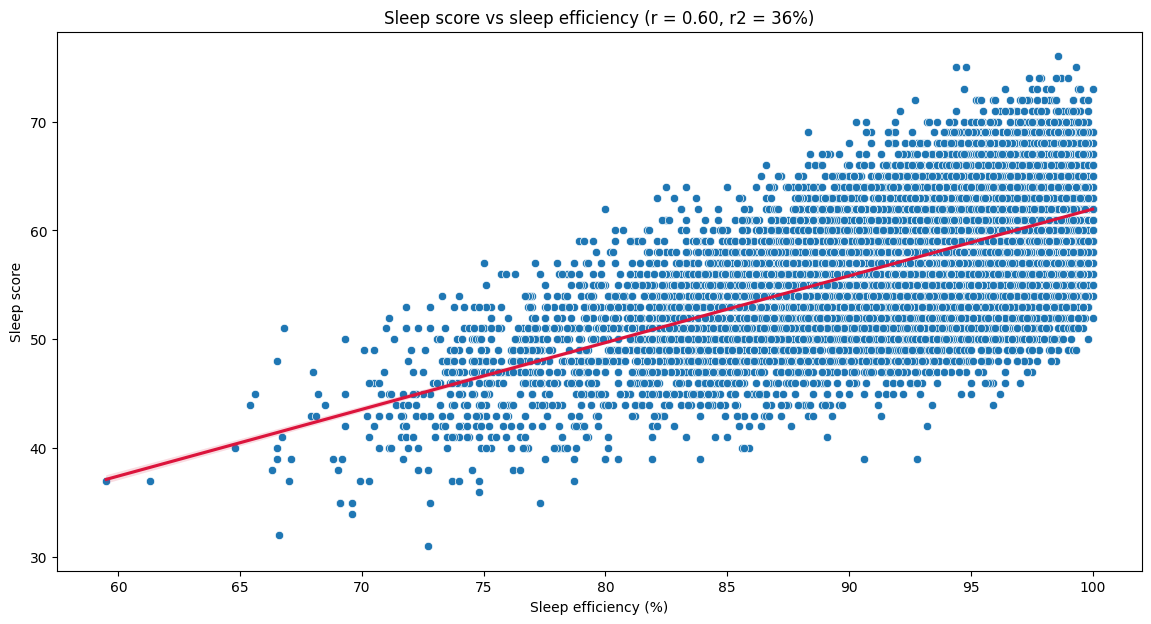

In [23]:
r = df["sleep_score"].corr(df["sleep_efficiency_pct"])
r_squared = (r**2)*100

plt.figure(figsize=(14, 7))

sns.scatterplot(data=df,
                x="sleep_efficiency_pct",
                y="sleep_score")

sns.regplot(data=df,
            x="sleep_efficiency_pct",
            y="sleep_score",
            scatter=False,
            line_kws={"color": "crimson"})

plt.title(f"Sleep score vs sleep efficiency (r = {r:.2f}, r2 = {r_squared:.0f}%)")
plt.xlabel("Sleep efficiency (%)")
plt.ylabel("Sleep score")
plt.show()

Sleep efficiency is positively correlated with overall sleep score (r = 0.60) which is a moderate relationship (36%) and is the stronget relationship in the dataset. The more efficient the night is (sleep efficiency = how much of your time in bed is actually spent asleep) the higher the sleep score.

# 🏆 KEY FINDINGS

**Question**: What is associated with longer deep sleep (in minutes)?

- 20000 sleep sessions from 2000 unique users (about 10 nights each), 45 columns, **fully synthetic**, no missing values. SpO2 and heart rate were checked for impossible values. All were physiologically plausible, so no rows were removed.

- Deep sleep distribution. Deep sleep is bell-shaped with a slight right skew. The median night has about 79 minutes of deep sleep, and roughly 39% of nights fall between 60 and 90 minutes.
No relationship with age. **Deep sleep shows no association with age** (r = 0.01). This is notable, because in the real world deep sleep declines with age. The flat result suggests this synthetic dataset did not encode that known pattern.

- **No lifestyle factor is associated with deep sleep**. Caffeine, alcohol, stress, screen time before bed, exercise, and weight all correlate near zero (r = 0.00 to 0.02). In this dataset, none of these behaviours or characteristics explains deep sleep.

- The one real link is sleep quality. **Deep sleep is positively correlated with overall sleep score** (r = 0.27), explaining about 7% of its variation. Nights with more deep sleep tend to score higher, which fits the idea that deep sleep is restorative. This is the only meaningful, non-mechanical relationship involving deep sleep.

- Beyond deep sleep. The strongest relationship in the whole dataset is between **sleep score and sleep efficiency (r = 0.60, about 36% of variation explained**). This is partly expected, since efficiency is one of the inputs to a sleep score. The dataset also show at least one realistic medical link: **weight and apnea risk (r = 0.8 about 64%).**

In this synthetic dataset, deep sleep duration tracks overall sleep quality but is not driven by any measurable behaviour or demographic factor. Because the data is synthetic, these results describe how the dataset was generated, not real human sleep.